In [2]:
import os
# Get the current working directory
current_dir = os.getcwd()
# Set the data directory to the parent directory of the current working directory
wdir = os.path.dirname(current_dir)
# Change the current working directory to the parent directory
os.chdir(wdir)

import sys
sys.path.append('src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import glob


In [3]:
# Set the font globally
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 9
rcParams['axes.titlesize'] = 9
rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9

In [9]:
# --------------------
# Load data
# --------------------
files = sorted(glob.glob("data/Supplementary_Fig_3/jump_traj_*.csv"))

trajectories_jump = []

for f in files:
    df = pd.read_csv(f)
    traj = df["value"].to_numpy()    # convert column to numpy array
    trajectories_jump.append(traj)


files = sorted(glob.glob("data/Supplementary_Fig_3/time_of_jump_traj_*.csv"))

jump_times = []

for f in files:
    df = pd.read_csv(f)
    traj = df["value"].to_numpy()    # convert column to numpy array
    jump_times.append(traj)

In [5]:
def cm2inch(x): return float(x)/2.54

plotwidth    = cm2inch(8.90)


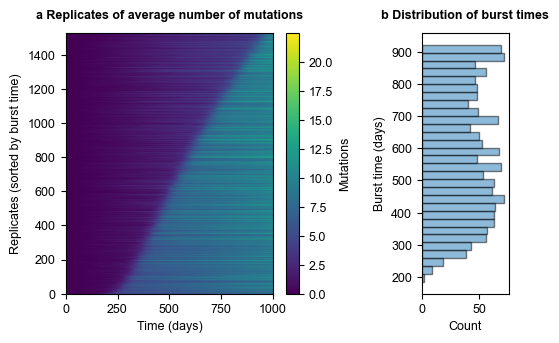

In [6]:
# ---- Process burst times ----
jump_times_flat = np.array([float(jt[0]) for jt in jump_times])
sorted_idx = np.argsort(jump_times_flat)

# ---- Build matrix for heatmap ----
mat_sorted = np.vstack([trajectories_jump[i] for i in sorted_idx])

# ---- Create figure ----
fig, (ax_heat, ax_hist) = plt.subplots(
    1, 2,
   figsize=(1.5*plotwidth, plotwidth),
    gridspec_kw={"width_ratios": [3, 1]}
)

# ==========================================
# 1. HEATMAP (left)
# ==========================================
im = ax_heat.imshow(
    mat_sorted,
    aspect='auto',
    origin='lower',
    cmap='viridis'
)

ax_heat.set_xlabel("Time (days)")
ax_heat.set_ylabel("Replicates (sorted by burst time)")
ax_heat.set_title(
    "a Replicates of average number of mutations",pad=10,weight='bold'
)

cbar = fig.colorbar(im, ax=ax_heat)
cbar.set_label("Mutations")

# ==========================================
# 2. HISTOGRAM (right)
# ==========================================
ax_hist.hist(
    jump_times_flat,
    bins=30,alpha=0.5,
    orientation='horizontal',
    edgecolor='black'
)

ax_hist.set_xlabel("Count")
ax_hist.set_ylabel("Burst time (days)")
ax_hist.set_title("b Distribution of burst times" ,pad=10,weight='bold')
plt.subplots_adjust(bottom=0.1,hspace=0.2,wspace=1.0)

plt.tight_layout()
plt.show()
